In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
pd.options.mode.use_inf_as_na = True
import tkinter
from tkinter import filedialog
import scipy as scp

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_12820\1395928006.py:8: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [2]:
import os
import pandas as pd

def data_to_dataframe(pathinfo, y_col='Y (cm)', x_col='X (cm)', speed_col='SPEED#wcentroid (cm/s)', vy_col='VY (cm/s)', frame_col='frame'):
    """
    Reads CSV files from a specified directory tree, extracts specific columns, and compiles them into a single pandas DataFrame.

    This function traverses the directory tree starting at `pathinfo`, identifies CSV files with "Trial" in their filenames,
    and extracts specific columns. It combines these extracted columns into a single DataFrame with additional metadata 
    about the trial and condition.

    Parameters:
    -----------
    pathinfo : str
        The root directory from which to start searching for CSV files.
    y_col : str, optional
        Column name for Y coordinates, default is 'Y (cm)'.
    x_col : str, optional
        Column name for X coordinates, default is 'X (cm)'.
    speed_col : str, optional
        Column name for speed, default is 'SPEED#wcentroid (cm/s)'.
    vy_col : str, optional
        Column name for Y velocity, default is 'VY (cm/s)'.
    frame_col : str, optional
        Column name for frame, default is 'frame'.

    Returns:
    --------
    pandas.DataFrame
        A DataFrame containing concatenated data from all relevant CSV files, with columns for Y, X, Speed, VY, Frame, Trial, and Condition.

    Notes:
    ------
    - The function assumes that the CSV files contain the specified columns.
    - The 'Trial' and 'Condition' columns are derived from the directory structure where the CSV files are found.
    - Uses os.path.join for cross-platform compatibility.

    Example:
    --------
    >>> df = data_to_dataframe("C:\\data\\experiments")
    >>> print(df.head())
    """
    
    df_files = []
    i = 0

    for root, dirs, files in os.walk(pathinfo):
        for f in files:
            if f.endswith(".csv") and "Trial" in f:
                file_path = os.path.join(root, f)
                try:
                    a = pd.read_csv(file_path)
                    data = {
                        "Y": a[y_col],
                        "X": a[x_col],
                        "Speed": a[speed_col],
                        "VY": a[vy_col],
                        "Frame": a[frame_col],
                        "Trial": os.path.basename(root),
                        "Condition": os.path.basename(os.path.dirname(root))
                    }
                    df_files.append(pd.DataFrame(data))
                    i += 1
                except KeyError as e:
                    print(f"Missing column in file {file_path}: {e}")
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    if df_files:
        complete_df = pd.concat(df_files, ignore_index=True)
    else:
        complete_df = pd.DataFrame()

    return complete_df

def clean_dataframe(df):
    """
    Cleans the DataFrame by dropping rows with missing values and filtering 
    rows based on the 'Speed' column.

    This function removes rows with any missing values and retains only rows 
    where the 'Speed' value is between 0.5 and 2.0 (exclusive).

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame to be cleaned.

    Returns:
    --------
    pandas.DataFrame
        The cleaned DataFrame with no missing values and 'Speed' values 
        between 0.5 and 2.0.
    
    Example:
    --------
    >>> df = data_to_dataframe("C:\\data\\experiments")
    >>> clean_df = clean_dataframe(df)
    >>> print(clean_df.head())
    """

    df_cleaned = df.dropna()
    df_cleaned = df_cleaned[df_cleaned["Speed"].between(0.5, 2.0, inclusive='neither')]
    return df_cleaned

def calculate_distance_from_fixed_point(df):
    """
    Calculates distance from a fixed point ('X_1', 'Y_1') to each row's ('X', 'Y') coordinates in the DataFrame.

    This function iterates over each row in the input DataFrame and calculates the Euclidean distance 
    from a fixed point ('X_1', 'Y_1') to each row's ('X', 'Y') coordinates.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing 'X', 'Y', 'Frame', 'Trial', and 'Condition' columns.

    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional column 'Distance' appended to the input DataFrame.

    Example:
    --------
    >>> df = pd.DataFrame({
    >>>     'X': [1, 2, 3],
    >>>     'Y': [4, 5, 6],
    >>>     'Frame': [1, 2, 3],
    >>>     'Trial': ['Trial1', 'Trial1', 'Trial2'],
    >>>     'Condition': ['Condition1', 'Condition1', 'Condition2']
    >>> })
    >>> df_processed = calculate_distance_from_fixed_point(df)
    >>> print(df_processed.head())
    """

    # Fixed point coordinates
    x_1 = 14
    y_1 = 2

    # Calculate distance for each row
    df['Distance'] = np.nan
    for idx, row in df.iterrows():
        x_2 = row['X']
        y_2 = row['Y']
        dist = math.sqrt((x_2 - x_1)**2 + (y_2 - y_1)**2)
        df.loc[idx, 'Distance'] = dist

    return df


In [3]:
import pandas as pd

def categorize_values(df: pd.DataFrame, column: str, value: float, width: float) -> pd.DataFrame:
    """
    Categorizes the values in the specified column of the DataFrame and adds the result
    as a new column called 'Preference Index'.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The column name to analyze.
        value (float): The reference value for comparison.
        width (float): The width of the interval around the reference value.

    Returns:
        pd.DataFrame: The DataFrame with a new column 'Preference Index' indicating
                      1 if value is greater than value+width,
                      0 if between value+width and value-width,
                      -1 if less than value-width.
    """
    df['Preference Index'] = df[column].apply(lambda x: 1 if x > value + width else 
                                                    0 if value - width <= x <= value + width else 
                                                   -1)
    return df

# Example usage:
# df = pd.DataFrame({'column_name': [1, 5, 7, 10]})
# df = categorize_values(df, 'column_name', 5, 2)
# print(df)

In [13]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = data_to_dataframe(filepath)

In [14]:
primary_df = primary_df[primary_df['Frame']<600]

In [15]:
primary_df = calculate_distance_from_fixed_point(primary_df)

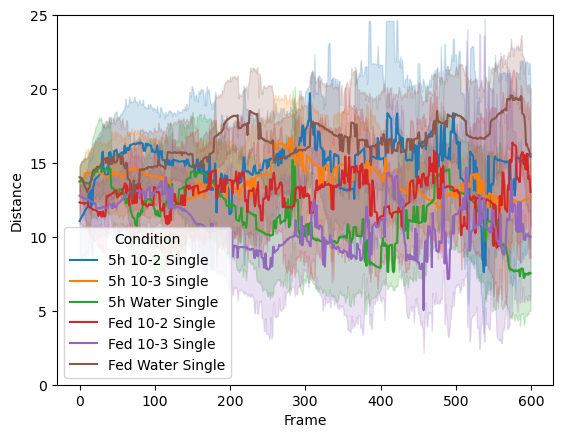

In [16]:
ax = sbs.lineplot(data = primary_df, x = 'Frame', y = 'Distance', hue = 'Condition')
plt.ylim(0,25)
plt.show()

In [7]:
primary_df = clean_dataframe(primary_df)
primary_df = categorize_values(primary_df, 'X', 14, 1.5)

In [8]:
# Create a modified subset with new values
subset = primary_df.loc[primary_df['Condition'] == '5h 10-3'].copy()
subset = categorize_values(subset, 'X', 12, 1.5)

# Update primary_df with the modified subset
primary_df.update(subset)

In [34]:
primary_df_10_3 = primary_df[(primary_df['Condition'] == '10-3') | (primary_df['Condition'] == '5h 10-3') | (primary_df['Condition'] == 'Trh 10-3') ] 
primary_df_10_4 = primary_df[(primary_df['Condition'] == '10-4') | (primary_df['Condition'] == '5h 10-4') | (primary_df['Condition'] == 'Trh 10-4') ]
primary_df_10_5 = primary_df[(primary_df['Condition'] == '10-5') | (primary_df['Condition'] == 'Trh 10-5')| (primary_df['Condition'] == '5h 10-5') ]  

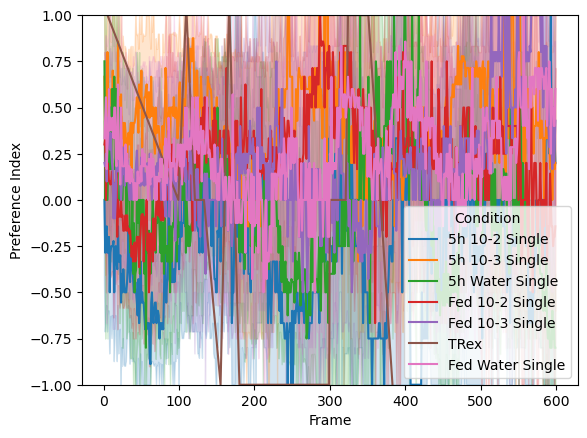

In [9]:
ax = sbs.lineplot(data = primary_df, x = 'Frame', y = 'Preference Index', hue = 'Condition')
plt.ylim(-1,1)
plt.show()

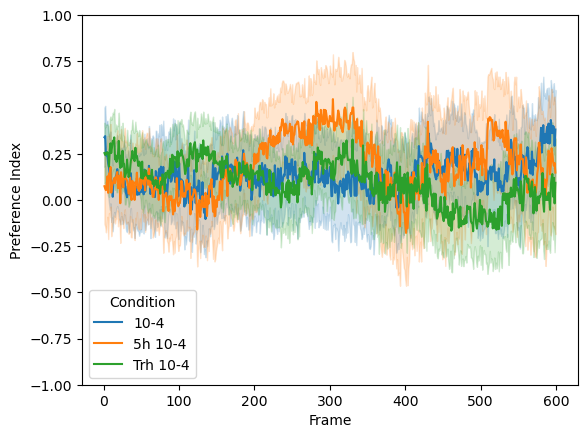

In [20]:
ax = sbs.lineplot(data = primary_df_10_4, x = 'Frame', y = 'Preference Index', hue = 'Condition')
plt.ylim(-1,1)
plt.show()

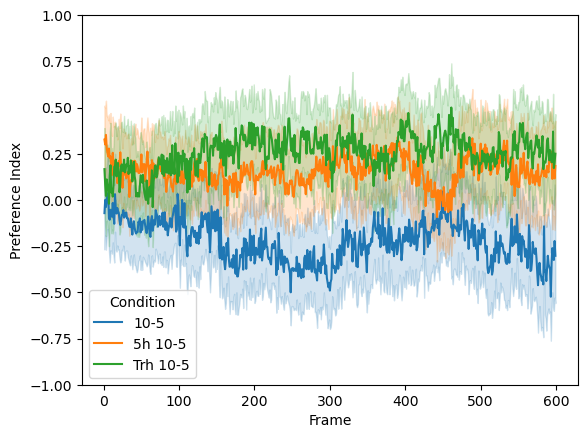

In [21]:
ax = sbs.lineplot(data = primary_df_10_5, x = 'Frame', y = 'Preference Index', hue = 'Condition')
plt.ylim(-1,1)
plt.show()

In [20]:
primary_df.head()

,Y,X,Speed,VY,Frame,Trial,Condition,Distance,Preference Index
10,14.173,11.700,0.651,0.063,34.0,Trial 1,5h 10-4 EtAc,2.306497,0
11,14.279,11.382,0.518,0.936,35.0,Trial 1,5h 10-4 EtAc,2.632825,0
16,14.250,11.465,0.586,-0.499,40.0,Trial 1,5h 10-4 EtAc,2.547298,0
19,14.305,11.351,0.682,-0.486,43.0,Trial 1,5h 10-4 EtAc,2.666501,0
20,14.347,11.278,0.887,-0.316,44.0,Trial 1,5h 10-4 EtAc,2.744029,0


C:\Users\hpnhp\AppData\Local\Temp\ipykernel_12820\2072618020.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_avg = primary_df.groupby(['Condition', 'Frame_Range'])['Preference Index'].mean().reset_index()


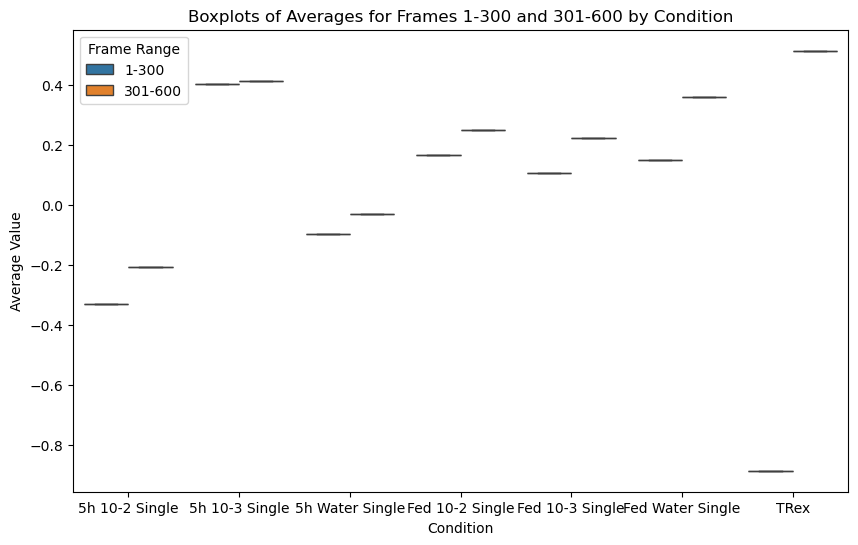

In [10]:
# Calculate the average for frames 1-300 and 301-600 for each condition
primary_df['Frame_Range'] = pd.cut(primary_df['Frame'], bins=[0, 300, 600], labels=['1-300', '301-600'])

# Group by 'Condition' and 'Frame_Range' to get the mean for each range
df_avg = primary_df.groupby(['Condition', 'Frame_Range'])['Preference Index'].mean().reset_index()

# Rename 'Value' to 'Average' for clarity
df_avg.rename(columns={'Preference Index': 'Average'}, inplace=True)

# Plot using seaborn
plt.figure(figsize=(10, 6))
sbs.boxplot(data=df_avg, x='Condition', y='Average', hue='Frame_Range')
plt.title('Boxplots of Averages for Frames 1-300 and 301-600 by Condition')
plt.xlabel('Condition')
plt.ylabel('Average Value')
plt.legend(title='Frame Range')
plt.show()

In [12]:
# Group by 'Condition' and 'Frame_Range' to calculate both the standard deviation and the count
df_stats = primary_df.groupby(['Condition', 'Frame_Range'])['Preference Index'].agg(['std', 'count']).reset_index()

# Rename columns for clarity
df_stats.rename(columns={'std': 'STD', 'count': 'Count'}, inplace=True)

# Display the resulting DataFrame to see the standard deviation and count of values used for each average
print(df_stats)

           Condition Frame_Range       STD  Count
0     5h 10-2 Single       1-300  0.787125   1905
1     5h 10-2 Single     301-600  0.854166   1215
2     5h 10-3 Single       1-300  0.824640   2430
3     5h 10-3 Single     301-600  0.835337   2013
4    5h Water Single       1-300  0.856850   2233
5    5h Water Single     301-600  0.819534   1549
6    Fed 10-2 Single       1-300  0.837324   2704
7    Fed 10-2 Single     301-600  0.890100   1655
8    Fed 10-3 Single       1-300  0.888144   2459
9    Fed 10-3 Single     301-600  0.824128   1760
10  Fed Water Single       1-300  0.925611   2579
11  Fed Water Single     301-600  0.863488   2142
12              TRex       1-300  0.428556    123
13              TRex     301-600  0.558849     37


C:\Users\hpnhp\AppData\Local\Temp\ipykernel_12820\1482002073.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = primary_df.groupby(['Condition', 'Frame_Range'])['Preference Index'].agg(['std', 'count']).reset_index()


In [52]:
print(f"Total rows in DataFrame: {len(primary_df_10_3)}")

Total rows in DataFrame: 98042


In [55]:
primary_df_10_3

,Y,X,Speed,VY,Frame,Trial,Condition,Distance,Preference Index,Frame_Range
3,10.416,7.926,0.516,0.596,3.0,Trial 1,10-3,10.378947,-1,1-300
28,11.082,8.084,0.510,-0.605,28.0,Trial 1,10-3,10.838901,-1,1-300
29,11.241,8.133,0.510,1.587,29.0,Trial 1,10-3,10.946130,-1,1-300
52,12.056,8.014,0.506,0.471,52.0,Trial 1,10-3,11.702792,-1,1-300
77,12.746,7.571,0.512,1.076,77.0,Trial 1,10-3,12.522322,-1,1-300
...,...,...,...,...,...,...,...,...,...,...
627365,14.186,8.058,0.598,-0.266,595.0,Trial 8,Trh 10-3,13.557506,-1,301-600
627366,14.040,8.318,0.785,-1.456,596.0,Trial 8,Trh 10-3,13.313404,-1,301-600
627367,13.969,8.365,0.802,-0.709,597.0,Trial 8,Trh 10-3,13.229142,-1,301-600
627368,13.894,8.429,0.968,-0.752,598.0,Trial 8,Trh 10-3,13.134050,-1,301-600


In [26]:
grouped_y = primary_df.groupby(["Condition","Frame"])["Y"].mean()
grouped_xy = primary_df.groupby(["Condition","Frame"])["X"].mean()

In [27]:
grouped_y = grouped_y.reset_index()
grouped_xy = grouped_xy.reset_index()

In [28]:
grouped_xy["Y"] = grouped_y["Y"]

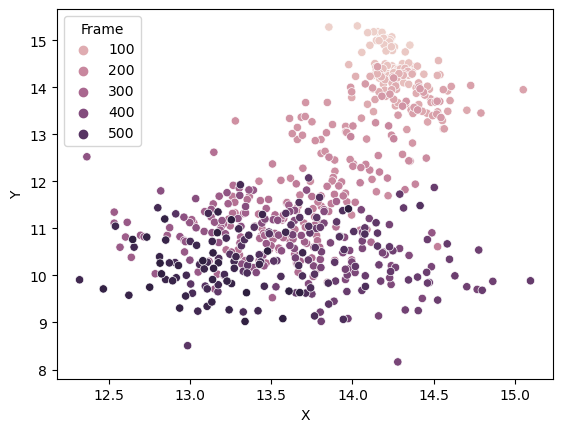

In [29]:
ax = sbs.scatterplot(grouped_xy[grouped_xy["Condition"] == "Trh 10-3"], x="X", y="Y", hue="Frame")

<Axes: xlabel='X', ylabel='Y'>

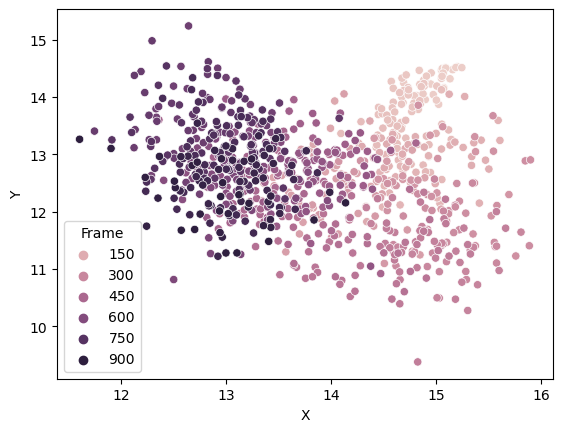

In [47]:
sbs.scatterplot(grouped_xy[grouped_xy["Condition"] == "5h 10-4 EtAc"], x="X", y="Y", hue="Frame")

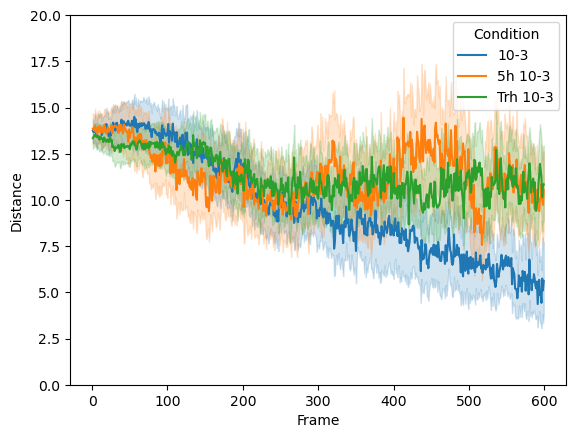

In [37]:
ax = sbs.lineplot(data = primary_df_10_3, x = 'Frame', y = 'Distance', hue = 'Condition')
plt.ylim(0,20)
plt.show()

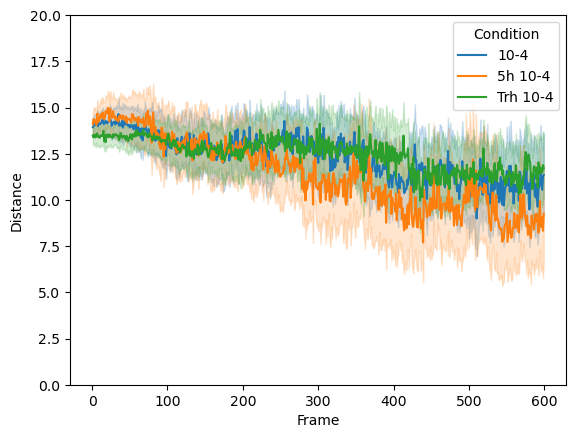

In [38]:
ax = sbs.lineplot(data = primary_df_10_4, x = 'Frame', y = 'Distance', hue = 'Condition')
plt.ylim(0,20)
plt.show()

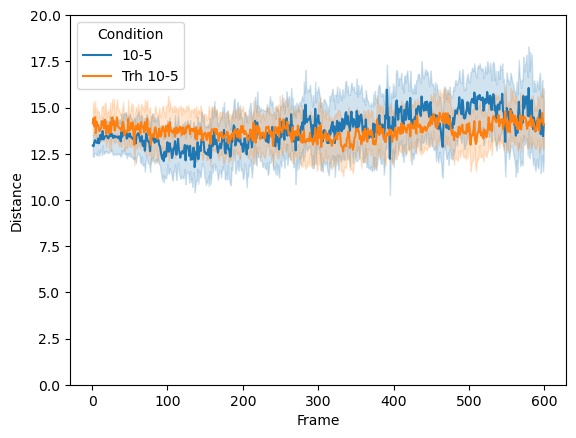

In [39]:
ax = sbs.lineplot(data = primary_df_10_5, x = 'Frame', y = 'Distance', hue = 'Condition')
plt.ylim(0,20)
plt.show()